In [75]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier,  bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter, plot_classification_with_grouping
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

In [76]:
# Set up experiment
def fit_gauss(counts, bins):
    params, cov = curve_fit(gaussian, bins[:-1], counts)
    return abs(params), cov

ROOT = Path("../sample_datasets/20221031_AmBe/")
AMPLITUDES_PATH = ROOT / "amplitudes.csv"
PSD_PATH =  ROOT / "psd.csv"

def load_psd_data(psd_path: Path, amplitudes_path: Path) -> pd.DataFrame:
    psd = pd.read_csv(PSD_PATH, header=None)
    amplitudes = pd.read_csv(AMPLITUDES_PATH, header=None)
    psd_report = pd.concat([psd, amplitudes], axis=1)
    psd_report.columns = ["tail / total", "amplitude"]
    return psd_report

psd_report = load_psd_data(PSD_PATH, AMPLITUDES_PATH)
psd_report = psd_report.dropna(axis=0)
psd_report = psd_report[psd_report["tail / total"].between(0,0.5)]

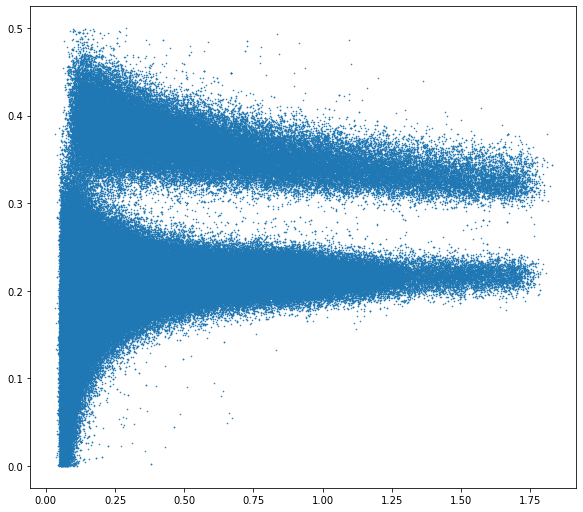

In [77]:
# Plot PSD
fig, ax = plot_scatter(psd_report["amplitude"], psd_report["tail / total"])
# ax.set_ylim(-0.5,0.5)
fig.set_figheight(7)
fig.set_figwidth(8)

# Converting Voltage to Light Output

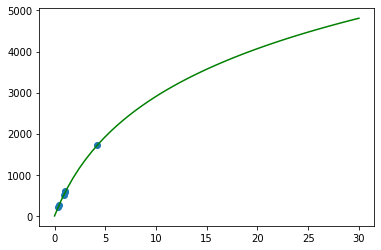

In [78]:
# plt.plot(np.linspace(0,5,50), exponential(np.linspace(0,5,50), *cali_params))

cal_x = np.array([0.4758, 1.0406, 0.9033, 0.3755, 1.0670, 4.1984])
cal_y = np.array([256.5, 581.87, 509.15, 206.8, 608.77, 1714.9]) 

def logarithmic(x, a, b, c):
    return a*np.log(b*x+1)+c*x


l_params, cov = curve_fit(
    logarithmic,
    cal_x,
    cal_y,
    bounds=((0, 0, 0),(20e3, 20, 3e3))
)

f_cal = np.poly1d(np.polyfit(cal_x, cal_y, 2))
# f_cal = interp1d(cal_x, cal_y, kind="quadratic", fill_value="extrapolate")



xspace = np.linspace(0,30,50)
# plt.plot(xspace, f_cal(xspace) ,'r')
plt.plot(xspace, logarithmic(xspace,*l_params) ,'g')
plt.scatter(cal_x, cal_y)
# plt.ylim(0, 2000)
# plt.xlim(0.75,1.25)

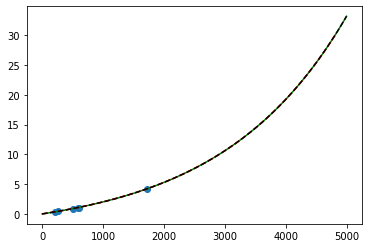

In [79]:
from pynverse import inversefunc
from scipy.interpolate import interp1d

plt.scatter(cal_y, cal_x)
yspace = np.linspace(0,5000,100)
inv_vals = inversefunc(lambda x: logarithmic(x, *l_params), y_values=yspace)
# inv_vals = inversefunc(lambda x: f_cal(x), y_values=yspace)
f_l = np.poly1d(np.polyfit(yspace, inv_vals, 9))
# f_l = interp1d(yspace, inv_vals, kind="cubic", fill_value="extrapolate")

plt.plot(yspace, inv_vals ,'g')
plt.plot(logarithmic(xspace,*l_params), xspace ,'r--')
plt.plot(yspace, f_l(yspace) ,'k--')

In [80]:
# def v_to_l(voltage):
#     V1 = 205 * 1e-3
#     L1 = 900 * 1e-3
#     V2 = 290 * 1e-3
#     L2 = 1200 * 1e-3

#     m = (L2-L1) / (V2-V1)
#     b =  L1 - m * V1
#     return m * voltage + b

def v_to_l(voltage):
    return f_l(voltage)

psd_report["energy"] = (psd_report["amplitude"] * 1e3).apply(v_to_l)

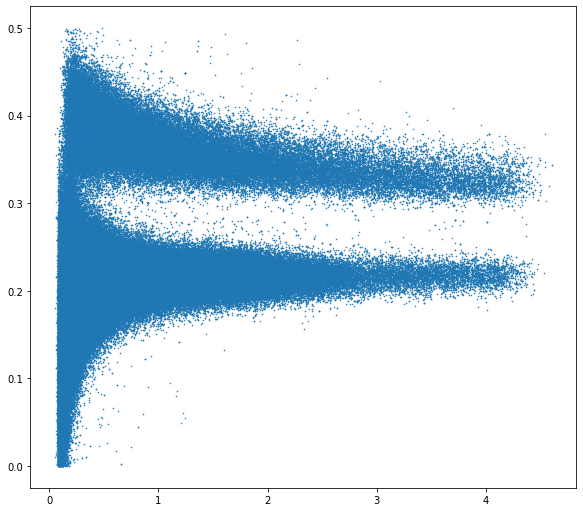

In [81]:
fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
fig.set_figheight(7)
fig.set_figwidth(8)
# ax.set_ylim(0,0.5)

In [82]:
def prep_df_for_slicing(dataframe, resolution):
    x, y = dataframe["energy"], dataframe["tail / total"]
    Z, xe, ye = np.histogram2d(x, y, resolution)
    return Z, xe, ye

def plot_histogram(Z, xe, ye):
    L4_e = xe[-2]  # what is this for?
    cmap = plt.colormaps["plasma"]
    plt.pcolormesh(xe, ye, Z.T, cmap=cmap)

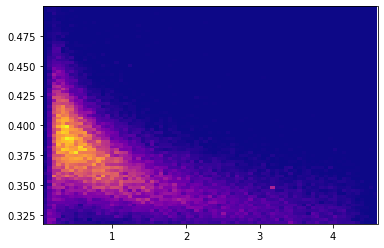

In [83]:
res = 75
lower_n_psd = 0.3175
neutron_psd = psd_report[psd_report["tail / total"].between(lower_n_psd, 0.5)]
# x, y = neutron_psd["energy"], neutron_psd["tail / total"]
# Z, xe, ye = np.histogram2d(x, y, 150)
# L4_e = xe[-2]  # what is this for?
# cmap = plt.colormaps["plasma"]
# plt.pcolormesh(xe, ye, Z.T, cmap=cmap)
Z, xe, ye = prep_df_for_slicing(neutron_psd, res)
plot_histogram(Z, xe, ye)
# plt.ylim(0,0.45)

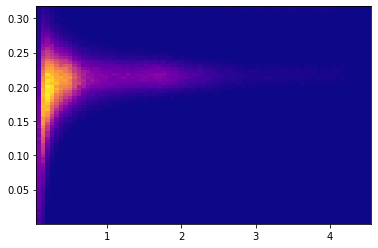

In [84]:
gamma_psd = psd_report[psd_report["tail / total"].between(0, lower_n_psd)]
# x, y = gamma_psd["energy"], gamma_psd["tail / total"]
# Z, xe, ye = np.histogram2d(x, y, 150)
# L4_e = xe[-2]
# cmap = plt.colormaps["plasma"]
# plt.pcolormesh(xe, ye, Z.T, cmap=cmap)
Z, xe, ye = prep_df_for_slicing(gamma_psd, res)
plot_histogram(Z, xe, ye)
# plt.ylim(0,0.45)

# TODO try not splitting this; instead, fit bimodal and just use n mu/sigma

In [85]:
# # just fit neutron slices to gaussian
# # result: not great!
# def sigma_slice(ye, counts, idx, lb, ub):
#     return curve_fit(
#         gaussian,
#         ye[:-1], 
#         counts[:,idx],
#         bounds=(lb,ub)
#     )


# def get_gamma_bound_point(xe, ye, counts, idx, lb, ub):
#     energy = (xe[idx] + xe[idx + 1]) / 2
#     (mu, sigma, A), cov = sigma_slice(ye, counts, idx, lb, ub)
    
#     return energy, mu, sigma
    

    
min_i = 4
end_slices_to_ignore = 20
max_i = len(xe) - (end_slices_to_ignore + 1)
min_counts = 1
max_counts = 30_000

# n_counts = Z.T
# n_energy = []
# n_sigma = []
# n_mu = []
# for idx in range(min_i, max_i):
#     e, m, s = get_gamma_bound_point(
#         xe, ye, n_counts, idx, 
#         lb=(0.33,0.001,min_counts), 
#         ub=(0.4,0.1,max_counts))
#     n_energy.append(e)
#     n_sigma.append(s)
#     n_mu.append(m)
    
    
# g_counts = Z.T
# g_energy = []
# g_sigma = []
# g_mu = []
# for idx in range(min_i, max_i):
#     e, m, s = get_gamma_bound_point(
#         xe, ye, g_counts, idx, 
#         lb=(0.1,0.001,min_counts), 
#         ub=(0.3,0.1,max_counts))
#     g_energy.append(e)
#     g_sigma.append(s)
#     g_mu.append(m)
    
# # trying to fit neutron edge
# # problem is in low/high energy slices
# # high energy slices are noisy, so mean/sigma can be way off
# # low energy slices can be thrown off by gamma data
# # but if we cut too close, we lose high E data and can't fit
# poly_n = 4

# def exp(x, a, b, c, d):
# #     return a*np.exp(b*x) + c*x + d
#     return a*np.exp(b*x) + c*np.exp(d*x)

energy_slice_xs = xe[min_i:max_i]

# fn_sigma = np.poly1d(np.polyfit(energy_slice_xs, n_sigma, poly_n))
# fn_mu = np.poly1d(np.polyfit(energy_slice_xs, n_mu, poly_n))

# sigma_width = 4
# def get_window_bound_points(mu_fn, sigma_fn, sigma_window, slice_xs):
#     return mu_fn(slice_xs) + sigma_window * sigma_fn(slice_xs)

# upper_params, _ = curve_fit(
#     exp, 
#     energy_slice_xs, 
#     get_window_bound_points(fn_mu, fn_sigma, sigma_width/2, energy_slice_xs)
# )
# lower_params, _ = curve_fit(
#     exp,
#     energy_slice_xs,
#     get_window_bound_points(fn_mu, fn_sigma, -sigma_width/2, energy_slice_xs)
# )

# fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
# fig.set_figheight(7)
# fig.set_figwidth(8)
# # ax.set_ylim(0,0.7)
# ax.plot(energy_slice_xs, exp(energy_slice_xs, *upper_params), 'k')
# ax.plot(energy_slice_xs, get_window_bound_points(fn_mu, fn_sigma, sigma_width/2, energy_slice_xs), 'r--')
# # ax.plot(energy_slice_xs, fn_mu(energy_slice_xs), 'k--')
# # ax.plot(energy_slice_xs, get_window_bound_points(fn_mu, fn_sigma, 1, energy_slice_xs), 'c3')
# ax.plot(energy_slice_xs, exp(energy_slice_xs, *lower_params), 'k')
# ax.plot(energy_slice_xs, get_window_bound_points(fn_mu, fn_sigma, -sigma_width/2, energy_slice_xs), 'r--')

In [86]:
# xe_r = np.linspace(0, xe[-1], 200)
# # plt.plot(xe[3:-1], lower_bound, 'r-')
# plt.plot(slice_x, fn_mu(slice_x))

# Bounding Box

Find the bounding box with `n` sigma tolerance. Change `n` if necessary.



In [87]:
def lo_output(Ep):
    return 0.748*Ep-2.41*(1-np.exp(-0.298*Ep))

L1, L2, L3 = lo_output(np.array([2.5, 4.0, 6.0]))

cutoffs = [L1, L2, L3]

In [88]:
# def f_lb(energy):
#     return fn_mu(energy) - 4 * fn_sigma(energy)

# def f_ub(energy):
#     return fn_mu(energy) + 4 * fn_sigma(energy)


# neutrons = psd_report[psd_report["tail / total"].between(f_lb(psd_report["energy"]), f_ub(psd_report["energy"]))]

# # plot distribution
# fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
# fig.set_figheight(7)
# fig.set_figwidth(8)
# ax.set_ylim(0,0.6)

# xe_r = np.linspace(xe[min_i], xe[-1], 200)

# # plot bounds
# ax.plot(xe_r, f_ub(xe_r), 'r-')
# ax.plot(xe_r, f_lb(xe_r), 'r-')

# # plot vlines
# ax.vlines(xe_r[0], f_lb(xe_r[0]), f_ub(xe_r[0]) ,'r')
# ax.vlines(xe_r[-1], f_lb(xe_r[-1]), f_ub(xe_r[-1]), 'r')

# # plot neutrons
# ax.scatter(neutrons["energy"], neutrons["tail / total"], marker="o", s=3, c="orange")

# ax.set_title(f"$N={neutrons.shape[0]}$", fontsize=18)
# ax.set_ylabel("PSD")
# ax.set_xlabel("Energy (MeVee)")

# for lo in cutoffs:
#     ax.vlines(lo, f_lb(lo), f_ub(lo), 'k')
    

In [89]:
# fig, ax, neutrons = classify_plot(psd_report, xe, f_lb)
# fig.tight_layout()

# Altogether

In [90]:
# bins = ["2.5", "4.5", "Control"]

# fig, ax = plt.subplots(figsize=(8,8))
# ax.errorbar(bins, rates_e, yerr=sigmas_e, fmt = "o", markersize=12, linestyle="", label="Echem", capsize=12)
# ax.errorbar(bins, rates_ep, yerr=sigmas_ep, fmt = "o", markersize=12, linestyle="", label="Echem + Plasma", capsize=12)
# ax.errorbar(bins, rates_p, yerr=sigmas_p, fmt = "o", markersize=12, linestyle="", label="Plasma", capsize=12)
# ax.errorbar(bins, rates_bg, yerr=sigmas_bg, fmt = "o", markersize=12, linestyle="", label="Background", capsize=8)

# ax.set_ylabel("Rate $(s^{{-1}})$", fontsize=26)
# ax.set_xlabel("Energy $(MeV)$", fontsize=26)
# # ax.set_ylim(0.0, 0.3)
# ax.set_yticks(np.arange(0,0.4,0.1))
# fig.suptitle("Date: Aug 31, 2022", fontsize=26)
# ax.tick_params(axis='both', which='major', labelsize=22)
# ax.tick_params(axis='both', which='minor', labelsize=22)
# ax.grid()
# ax.legend(fontsize=18)
# fig.tight_layout()
# plt.show()

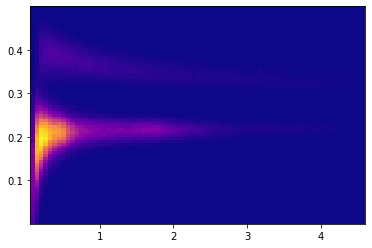

In [91]:
# generating psd/energy 2D histogram
resolution = 75
lim_psd = psd_report[psd_report["tail / total"].between(0, 0.5)]
x, y = lim_psd["energy"], lim_psd["tail / total"]
Z, xe, ye = np.histogram2d(x, y, resolution)
cmap = plt.colormaps["plasma"]
plt.pcolormesh(xe, ye, Z.T, cmap=cmap)
# plt.ylim(0,0.45)

In [92]:
# slice width
f"{xe[2] - xe[1]:.4f} MeVee"

'0.0607 MeVee'

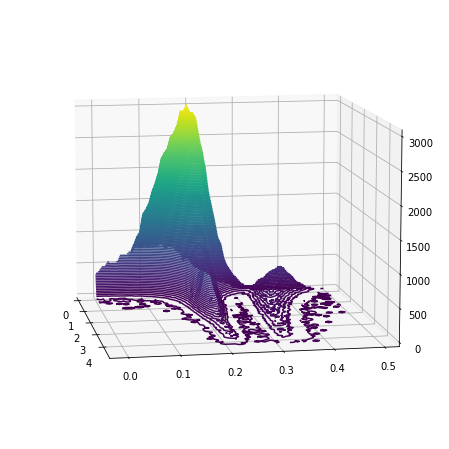

In [93]:
# histogram contour plot (vaporwave island)
contour_res = 150
angle_elev = 10
angle_rot = -10

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')

x, y = np.meshgrid(xe[:-1], ye[:-1])
ax.view_init(angle_elev, angle_rot)
ax.contour3D(x, y, Z.T, contour_res)

In [94]:
# defining settings for ?
psd_bin_lbs = ye[:-1]
# TODO programmatically get max count
fit_bounds = (
    (0.10,0.0001,1,0.3,0.0001,1),
    (0.3,0.2,28e3,0.4,0.1,28e3)
)

In [95]:
def split_params(params):
    params = abs(params)
    return params[0:3], params[3:]


In [96]:
def log_bimodal(x, mu1, sigma1, a1, mu2, sigma2, a2):
    return np.log(bimodal(x, mu1, sigma1, a1, mu2, sigma2, a2))

def scan_histogram_slices(bin_lbs, histogram, bounds, start_idx, end_idx):
    # end_idx is not inclusive (like end of range())
    end_idx = min(len(histogram), end_idx)
    slice_params = []
    slice_err = []
    for i in range(start_idx, end_idx):
        params, cov = curve_fit(
        bimodal,
        bin_lbs,
        histogram[:,i],
        bounds=bounds
    )
        perr = np.sqrt(np.diag(cov))
        gamma_params, neutron_params = split_params(params)
        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])
        slice_params.append((i, *params, fom))
        slice_err.append((i, *perr))

    df = pd.DataFrame(slice_params, columns=['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2', 'fom'])
    err_df = pd.DataFrame(slice_err, columns=['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2'])
    return df, err_df

def find_threshold_fom_slice(bin_lbs, histogram, bounds, start_idx, end_idx):
    # end_idx is not inclusive (like end of range())
    # TODO redefine in terms of scan_histogram_slices()
    end_idx = min(len(histogram), end_idx)
    for i in range(start_idx, end_idx):
        params, _ = curve_fit(
        bimodal,
        bin_lbs,
        histogram[:,i],
        bounds=bounds
    )

        gamma_params, neutron_params = split_params(params)

        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])

        if round(fom, 3) >= 1.269:
            return i, params

In [97]:
# getting threshold FOM slice index
fom_idx, params = find_threshold_fom_slice(psd_bin_lbs, Z.T, fit_bounds, 2, 200)
fom_idx

5

Text(0.5, 1.0, 'FOM=1.323')

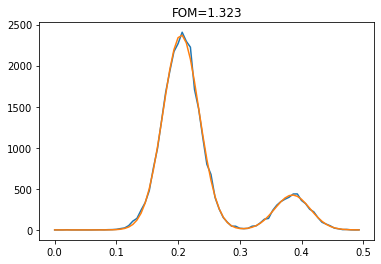

In [98]:
# looking at threshold FOM slice
histogram_slice = Z.T[:,fom_idx]

# params, _ = curve_fit(
#     bimodal,
#     psd_bin_lbs, 
#     histogram_slice,
#     bounds=fit_bounds
# )

plt.plot(psd_bin_lbs, histogram_slice)
plt.plot(psd_bin_lbs, bimodal(psd_bin_lbs, *params))

gamma_params, neutron_params = split_params(params)

plt.title(f"FOM={FOM(*gamma_params[:-1], *neutron_params[:-1]):.3f}")

In [99]:
# TODO programmatically check multiple resolutions and get ideal FOM slice
# (also graphs)

In [100]:
# scan PSD/energy histogram
df, err_df = scan_histogram_slices(psd_bin_lbs, Z.T, fit_bounds, 0, 200)

In [70]:
df.head()

,i,mu1,sigma1,a1,mu2,sigma2,a2,fom
0,0,0.187163,0.051003,4262.495466,0.356082,0.000808,19.614839,1.384524
1,1,0.200280,0.031894,5315.042586,0.388130,0.027188,13.336181,1.350189
2,2,0.204286,0.023937,4130.553042,0.368011,0.028619,9.416282,1.322942
3,3,0.205882,0.020025,3195.615497,0.355340,0.001988,35.394284,2.883366
4,4,0.207014,0.017375,2842.929429,0.355879,0.001829,37.820312,3.291875


In [27]:
# super-awesome histogram scan animation
%matplotlib notebook
from matplotlib.animation import FuncAnimation

fig = plt.figure(figsize=(6,6))
ax = plt.axes(xlim=(0, 0.5), ylim=(0,3000))

line1, = ax.plot([], [], 'k', lw=3, label='Actual')
line2, = ax.plot([], [], 'r--', lw=3, label='Fit')

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    ax.legend()
    ax.set_xlabel('PSD')
    ax.set_ylabel('N')
    return line1, line2
def animate(i):
    x = psd_bin_lbs
    y = Z.T[:,i]
    line1.set_data(x, y)
    params = tuple(df.iloc[i,1:7])
    fom = df['fom'][i]
    y = bimodal(x, *params)
    line2.set_data(x, y)
#     mu1, _, a1, mu2, _, a2 = params
#     ax.vlines([mu1, mu2], [0, 0], [a1, a2])
    ax.set_title(f"i={i}, E={xe[i]:.3f} MeVee, FOM={fom:.3f}")

    return line1, line2

anim = FuncAnimation(fig, animate, init_func=init, frames=len(psd_bin_lbs), interval=160, blit=True)
anim.save('psd_slice_scan.gif', writer='pillow')

<IPython.core.display.Javascript object>

In [28]:
%matplotlib inline

In [104]:
def fit_to_poly(x, y, degree):
    return np.poly1d(np.polyfit(x, y, degree))

def get_param_slice(dataframe, col_label, min, max):
    return dataframe[col_label][min:max]

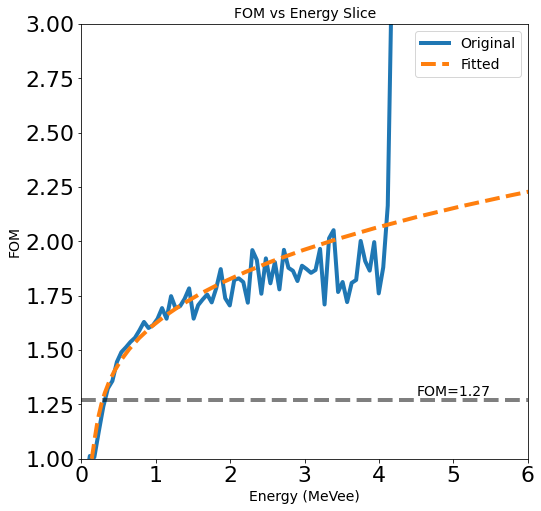

In [109]:
# index vs FOM
# fom_fit = fit_to_poly(df['fom'][2:-30], xe[2:-31], 4)
# fom_space = np.linspace(1, 1.9, 100)
# plt.plot(xe[:-1], df['fom'])
# plt.plot(fom_fit(fom_space), fom_space)
# plt.ylim(1,2)
# plt.hlines(1.27, 0, resolution, color='r', linestyle='--')
# plt.xlim(0,3)

fontsize = 14
# index vs FOM
fom_fit = fit_to_poly(df['fom'][0:30], xe[0:30], 3)
fom_space = np.linspace(1, 6, 100)

fig, ax = plt.subplots(figsize=(8,8))

ax.plot(xe[:-1], df['fom'], label="Original", lw=4)
ax.plot(fom_fit(fom_space), fom_space, '--', label="Fitted", lw=4)
ax.hlines(1.27, 0, resolution, color='k', linestyle='--', alpha=0.5, lw=4)
ax.text(*(4.5, 1.27 + 0.02), "FOM=1.27", fontsize=fontsize)

ax.set_ylim(1,3)
ax.set_xlim(0,6)

ax.set_title("FOM vs Energy Slice", fontsize=fontsize)
ax.set_ylabel("FOM", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)

ax.legend(fontsize=fontsize)

# ax.set_yticks(np.arange(1,3,0.25))
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

In [31]:
L0 = fom_fit(1.27)
cutoffs.append(L0)
L0

0.3017482831061913

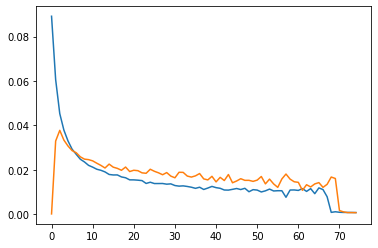

In [32]:
# index vs sigma
plt.plot(range(0, resolution), df['sigma1'], df['sigma2'])

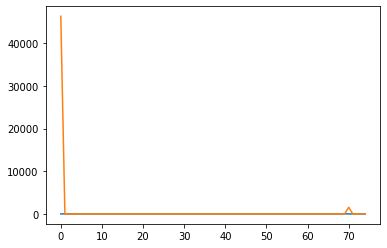

In [33]:
# index vs. sigma error
plt.plot(range(0, resolution), err_df['sigma1'], err_df['sigma2'])

In [34]:
# settings for window fitting
poly_degree = 4  # TODO need this?
n_window_height = 4
g_window_height = 8
max_slice_idx = 63  # TODO determine programmatically

n_window_offset = n_window_height/2
g_window_offset = g_window_height/2
min_slice_idx = fom_idx

all_slice_xs = xe[:-1]
fitting_slice_xs = xe[min_slice_idx:max_slice_idx]

In [35]:
def interp(x, y):
    return interp1d(x, y, "previous", fill_value="extrapolate")

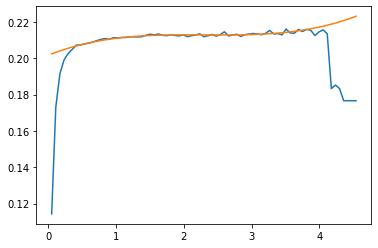

In [36]:
# mu1 fitting
mu1_fit = fit_to_poly(fitting_slice_xs, get_param_slice(df, 'mu1', min_slice_idx, max_slice_idx), 3)
# mu1_fit = interp(fitting_slice_xs, get_param_slice(df, 'mu1', min_slice_idx, max_slice_idx))

plt.plot(all_slice_xs, df['mu1'])
plt.plot(all_slice_xs, mu1_fit(all_slice_xs))

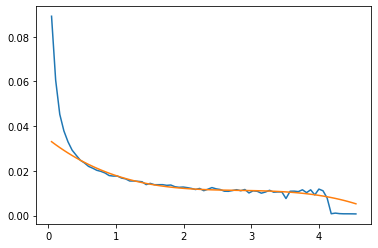

In [37]:
# sigma1 fitting
sigma1_fit = fit_to_poly(fitting_slice_xs, get_param_slice(df, 'sigma1', min_slice_idx, max_slice_idx), 3)
# sigma1_fit = interp(fitting_slice_xs, get_param_slice(df, 'sigma1', min_slice_idx, max_slice_idx))

plt.plot(all_slice_xs, df['sigma1'])
plt.plot(all_slice_xs, sigma1_fit(all_slice_xs))
# QUESTION do we need to be tighter to real vals at low E?
# we didn't with mu1...

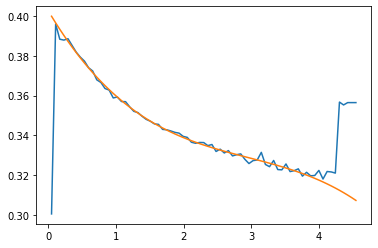

In [38]:
# mu2 fitting
mu2_fit = fit_to_poly(fitting_slice_xs, get_param_slice(df, 'mu2', min_slice_idx, max_slice_idx), 3)
# mu2_fit = interp(fitting_slice_xs, get_param_slice(df, 'mu2', min_slice_idx, max_slice_idx))

plt.plot(all_slice_xs, df['mu2'])
plt.plot(all_slice_xs, mu2_fit(all_slice_xs))

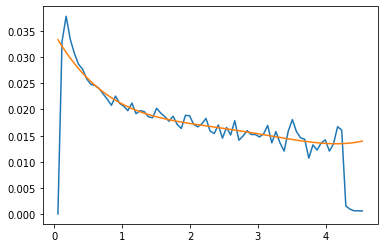

In [39]:
# sigma2 fitting
sigma2_fit = fit_to_poly(fitting_slice_xs, get_param_slice(df, 'sigma2', min_slice_idx, max_slice_idx), 4)
# sigma2_fit = interp(fitting_slice_xs, get_param_slice(df, 'sigma2', min_slice_idx, max_slice_idx))
plt.plot(all_slice_xs, df['sigma2'])
plt.plot(all_slice_xs, sigma2_fit(all_slice_xs))
# low E fit problems again...

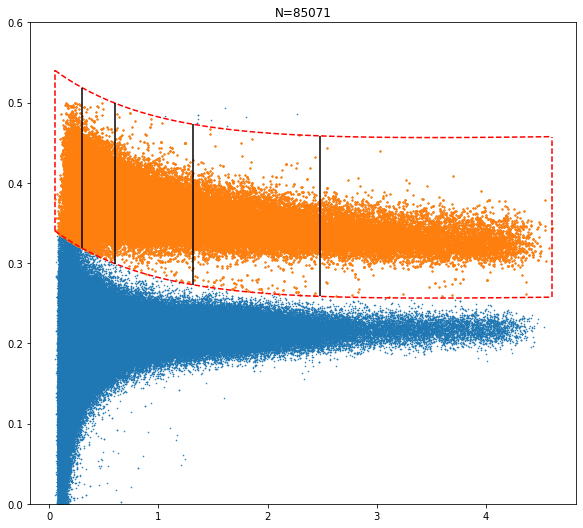

In [40]:
# window fitting
# lb_fit = np.poly1d(np.polyfit(fitting_slice_xs, mu1_fit(fitting_slice_xs)+g_window_offset*sigma1_fit(fitting_slice_xs), 3))
# lb_fit = interp1d(fitting_slice_xs, mu1_fit(fitting_slice_xs)+g_window_offset*sigma1_fit(fitting_slice_xs), "quadratic", fill_value="extrapolate")

# ub_fit = np.poly1d(np.polyfit(fitting_slice_xs, 0.2 + (mu1_fit(fitting_slice_xs)+g_window_offset*sigma1_fit(fitting_slice_xs)), 3))
# ub_fit = np.poly1d(np.polyfit(fitting_slice_xs, mu2_fit(fitting_slice_xs)+g_window_offset*sigma2_fit(fitting_slice_xs), 3))
# ub_fit = np.poly1d(np.polyfit(fitting_slice_xs, mu2_fit(fitting_slice_xs)+8*sigma1_fit(fitting_slice_xs), 4))

def exponential(x, a, b, c, d):
    return a*np.exp(b*x) + c*np.exp(d*x)

lb_fit_params, _ = curve_fit(
    exponential,
    fitting_slice_xs,
    mu1_fit(fitting_slice_xs)+g_window_offset*sigma1_fit(fitting_slice_xs),
)

def lb_fit(energy):
    return exponential(energy, *lb_fit_params)

def ub_fit(energy):
    return lb_fit(energy) + 0.2

neutron_filter = psd_report["tail / total"].between(lb_fit(psd_report["energy"]),ub_fit(psd_report["energy"]))
neutrons = psd_report[neutron_filter]
gammas = psd_report[~neutron_filter]


fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
ax.scatter(neutrons["energy"], neutrons["tail / total"], s=2)


ax.plot(xe, lb_fit(xe), 'r--')
ax.plot(xe, ub_fit(xe), 'r--')
ax.vlines(all_slice_xs[0], lb_fit(all_slice_xs[0]), ub_fit(all_slice_xs[0]), 'r', ls='--')
ax.vlines(psd_report["energy"].max(), lb_fit(psd_report["energy"].max()), ub_fit(psd_report["energy"].max()), 'r', ls='--')




for ep in cutoffs:
    ax.vlines(ep, lb_fit(ep), ub_fit(ep), 'k')


ax.set_title(f"N={neutrons.shape[0]}")
ax.set_ylim(0,0.6)
fig.set_figheight(7)
fig.set_figwidth(8)

# TEST

In [41]:
# summer_psd = load_psd_data(, AMPLITUDES_PATH)

SUMMER_PATH = Path("../sample_datasets/20220801_experiments/echem_plasma/")

total_tail = pd.read_csv(SUMMER_PATH / "total-tail.csv", header=None)
summer_psd = total_tail.loc[:,1] / total_tail.loc[:,0] 
summer_amps = pd.read_csv(SUMMER_PATH / "amplitudes.csv", header=None)
summer_report = pd.concat([summer_psd, summer_amps], axis=1)
summer_report.columns = ["tail / total", "amplitude"]

summer_report = summer_report.dropna(axis=0)
summer_report = summer_report[summer_report["tail / total"].between(0,0.5)]
summer_report["energy"] = (summer_report["amplitude"] * 1e3).apply(v_to_l)

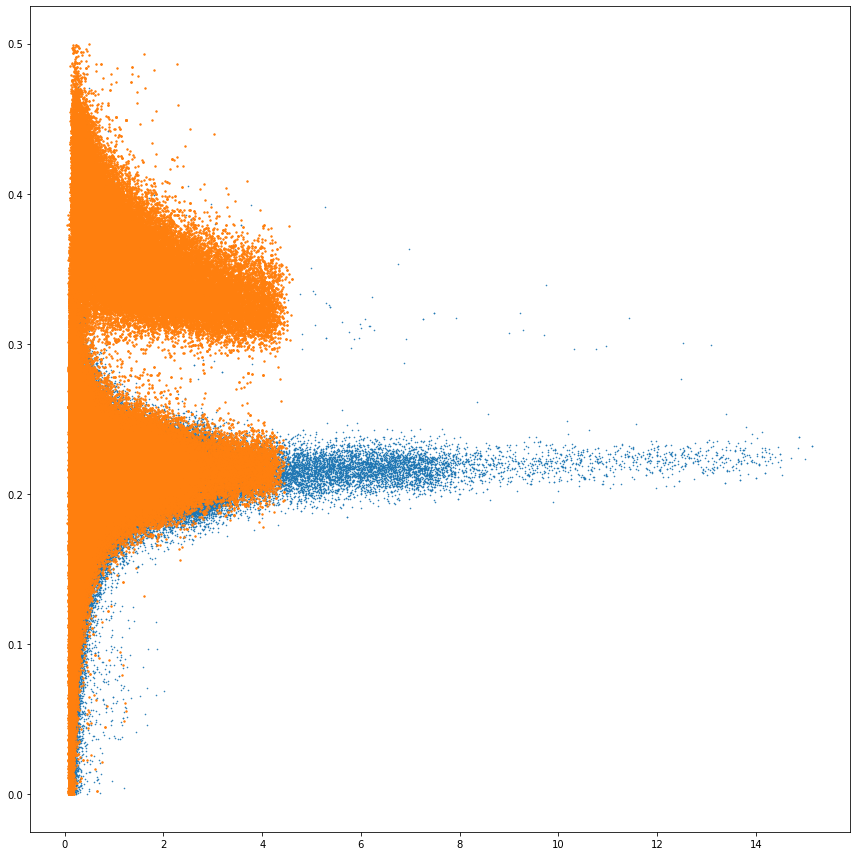

In [42]:
fig, ax = plot_scatter(summer_report["energy"], summer_report["tail / total"])
ax.scatter(psd_report["energy"], psd_report["tail / total"], s=2)

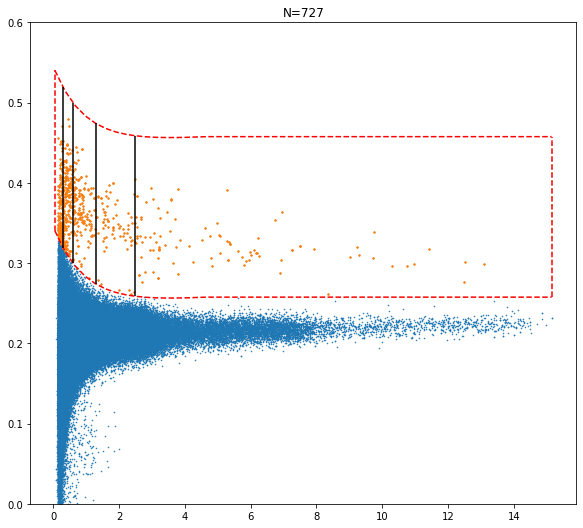

In [43]:
# window fitting
exp_interp = interp(xe, lb_fit(xe))

def lb_fit(energy):
    return exp_interp(energy)

def ub_fit(energy):
    return lb_fit(energy) + 0.2

neutron_filter = summer_report["tail / total"].between(lb_fit(summer_report["energy"]),ub_fit(summer_report["energy"]))
neutrons = summer_report[neutron_filter]

fig, ax = plot_scatter(summer_report["energy"], summer_report["tail / total"])
ax.scatter(neutrons["energy"], neutrons["tail / total"], s=2)

energy_space = np.linspace(xe[0], summer_report["energy"].max())

ax.plot(energy_space, lb_fit(energy_space), 'r--')
ax.plot(energy_space, ub_fit(energy_space), 'r--')

ax.vlines(all_slice_xs[0], lb_fit(all_slice_xs[0]), ub_fit(all_slice_xs[0]), 'r', ls='--')
ax.vlines(energy_space[-1], lb_fit(energy_space[-1]), ub_fit(energy_space[-1]), 'r', ls='--')

for ep in cutoffs:
    ax.vlines(ep, lb_fit(ep), ub_fit(ep), 'k')


ax.set_title(f"N={neutrons.shape[0]}")
ax.set_ylim(0,0.6)
fig.set_figheight(7)
fig.set_figwidth(8)

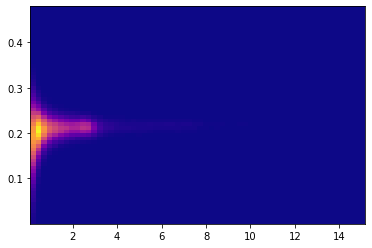

In [44]:
# generating psd/energy 2D histogram
resolution = 60
lim_psd = summer_report[summer_report["tail / total"].between(0, 0.5)]
x, y = lim_psd["energy"], lim_psd["tail / total"]
Z, xe, ye = np.histogram2d(x, y, resolution)
cmap = plt.colormaps["plasma"]
plt.pcolormesh(xe, ye, Z.T, cmap=cmap)

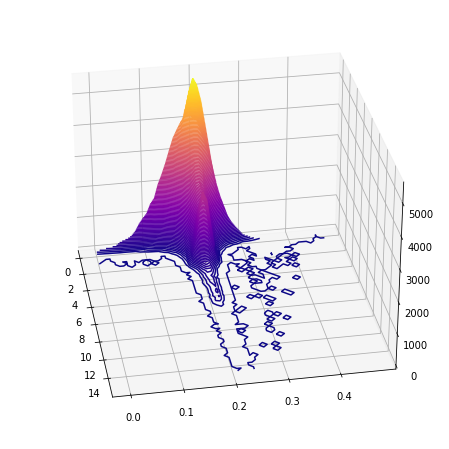

In [45]:
# histogram contour plot (vaporwave island)
fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')

x, y = np.meshgrid(xe[:-1], ye[:-1])
ax.view_init(30, angle_rot)
ax.contour3D(x, y, Z.T, 150, cmap=cmap)

In [46]:
fit_bounds = (
    (0.10,0.0001,1,0.3,0.0001,1),
    (0.3,0.2,50e3,0.4,0.1,50e3)
)
df, err_df = scan_histogram_slices(ye[:-1], Z.T, fit_bounds, 0, 200)

In [47]:
# super-awesome histogram scan animation
%matplotlib notebook
fig = plt.figure(figsize=(6,6))
ax = plt.axes(xlim=(0, 0.5), ylim=(0,5e3))

line1, = ax.plot([], [], 'k', lw=3, label='Actual')
line2, = ax.plot([], [], 'r--', lw=3, label='Fit')

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    ax.legend()
    ax.set_xlabel('PSD')
    ax.set_ylabel('N')
    return line1, line2
def animate(i):
    x = ye[:-1]
    y = Z.T[:,i]
    line1.set_data(x, y)
    params = tuple(df.iloc[i,1:4])
    fom = df['fom'][i]
    y = gaussian(x, *params)
    line2.set_data(x, y)
#     mu1, _, a1, mu2, _, a2 = params
#     ax.vlines([mu1, mu2], [0, 0], [a1, a2])
    ax.set_title(f"i={i}, E={xe[i]:.3f} MeVee, FOM={fom:.3f}")

    return line1, line2

anim = FuncAnimation(fig, animate, init_func=init, frames=len(xe[:-1]), interval=160, blit=True)
anim.save('psd_slice_scan_test.gif', writer='pillow')

<IPython.core.display.Javascript object>

In [48]:
%matplotlib inline

In [49]:
lb_fit_params

array([ 0.24552786,  0.00976097,  0.0998435 , -1.0741315 ])